## **Part 4: Data Visualization & Machine Learning**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving students.csv to students (2).csv
User uploaded file "students (2).csv" with length 536 bytes


**Task 1 — Data Exploration with Pandas**

In [3]:
# First 5 rows

df = pd.read_csv("students.csv")
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [4]:
# Shape and dtypes

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary:\n", df.describe().round(2))

Shape: (15, 9)

Data Types:
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary:
         math  science  english  history     pe  attendance_pct  \
count  15.00    15.00    15.00    15.00  15.00           15.00   
mean   65.00    66.73    66.20    63.40  74.80           75.80   
std    20.06    18.97    17.77    16.94  16.66           14.72   
min    30.00    35.00    40.00    28.00  45.00           50.00   
25%    51.50    53.50    49.00    53.50  61.00           63.50   
50%    65.00    65.00    70.00    62.00  75.00           78.00   
75%    80.00    77.00    81.00    73.50  89.00           86.50   
max    95.00    98.00    91.00    92.00  97.00           98.00   

       study_hours_per_day  passed  
count                15.00   15.00 

In [5]:
# Pass/Fail count

print("Pass / Fail Count")
print(df["passed"].value_counts().rename({1: 'Pass', 0: 'Fail'}))

Pass / Fail Count
passed
Pass    9
Fail    6
Name: count, dtype: int64


In [6]:
#Average Score

subject_cols = ['math', 'science', 'english', 'history', 'pe']
pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()
print("\nAverage Subject Scores: Pass students")
print(pass_avg.round(2))
print("\nAverage Subject Scores: Fail students")
print(fail_avg.round(2))


Average Subject Scores: Pass students
math       78.22
science    78.56
english    79.11
history    73.44
pe         86.00
dtype: float64

Average Subject Scores: Fail students
math       45.17
science    49.00
english    46.83
history    48.33
pe         58.00
dtype: float64


In [7]:
# Finding the Top Student

df["avg_score"] = df[subject_cols].mean(axis=1)
top = df.loc[df["avg_score"].idxmax()]

print("Top Student:", top["name"], "-", top["avg_score"])

Top Student: Diana - 94.0


**Task 2 — Data Visualization with Matplotlib**

In [8]:
# Adding a new column to df

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

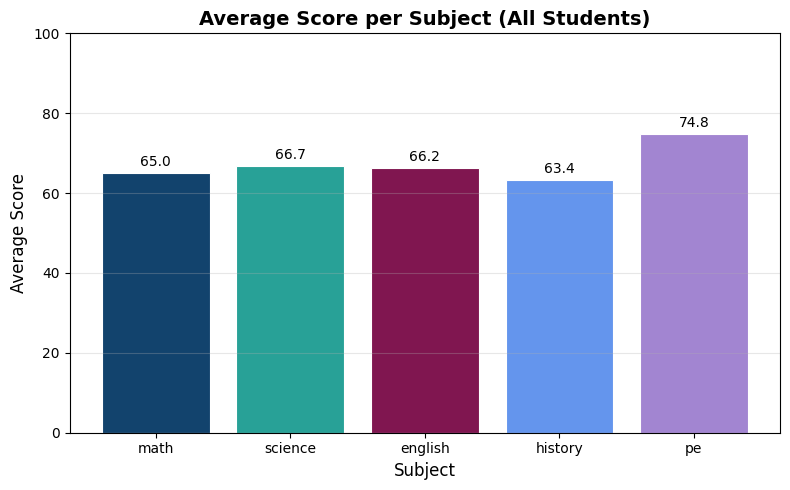

✓ Saved plot1_bar.png


In [9]:
# Creating the Bar Chart

fig, ax = plt.subplots(figsize=(8, 5))
subject_means = df[subject_cols].mean()
colors = ['#12436D', '#28A197', '#801650', '#6495ED', '#A285D1']
bars = ax.bar(subject_cols, subject_means, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Average Score per Subject (All Students)', fontsize=14, fontweight='bold')
ax.set_xlabel('Subject', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.set_ylim(0, 100)
for bar, val in zip(bars, subject_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot1_bar.png', dpi=150)
plt.show()
print("✓ Saved plot1_bar.png")

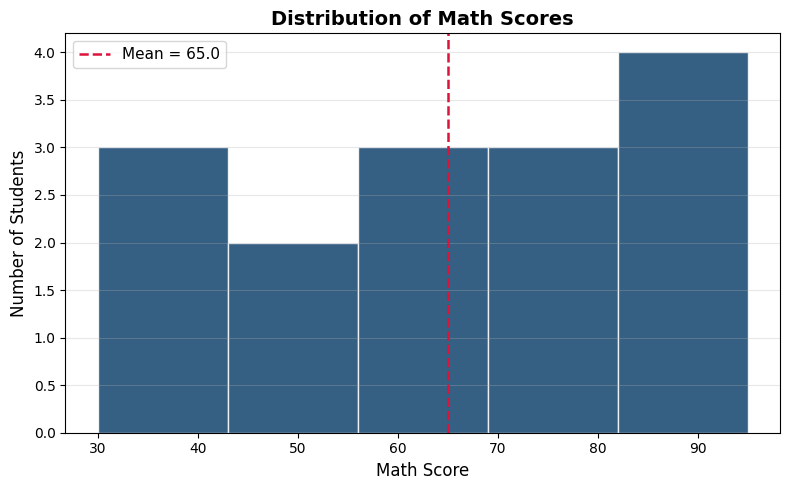

✓Saved plot2_histogram.png


In [10]:
# Creating the Histogram

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['math'], bins=5, color='#12436D', edgecolor='white', alpha=0.85)
mean_math = df['math'].mean()
ax.axvline(mean_math, color='crimson', linestyle='--', linewidth=1.8,
        label=f'Mean = {mean_math:.1f}')
ax.set_title('Distribution of Math Scores', fontsize=14, fontweight='bold')
ax.set_xlabel('Math Score', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot2_histogram.png', dpi=150)
plt.show()
print("✓Saved plot2_histogram.png")

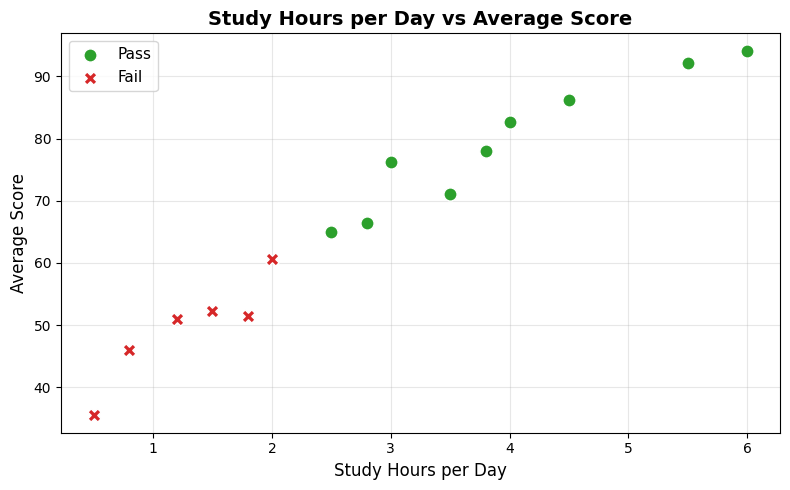

✓Saved plot3_scatter.png


In [11]:
# Creating the Scatter plot

fig, ax = plt.subplots(figsize=(8, 5))
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]
ax.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'],
        color='#2ca02c', s=90, label='Pass', zorder=3, edgecolors='white')
ax.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'],
        color='#d62728', s=90, label='Fail', zorder=3, edgecolors='white', marker='X')
ax.set_title('Study Hours per Day vs Average Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Study Hours per Day', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot3_scatter.png', dpi=150)
plt.show()
print("✓Saved plot3_scatter.png")

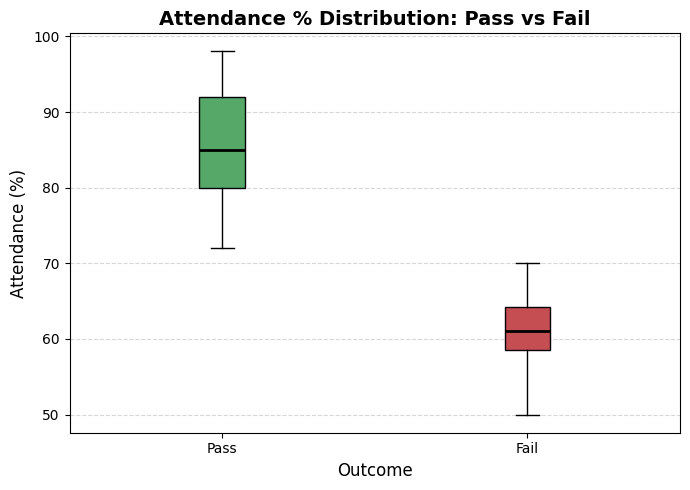

✓Saved: plot4_boxplot.png


In [12]:
# Creating the Box Plot

fig, ax = plt.subplots(figsize=(7, 5))
pass_attendance = df[df["passed"] == 1]["attendance_pct"].tolist()
fail_attendance = df[df["passed"] == 0]["attendance_pct"].tolist()
bp = ax.boxplot([pass_attendance, fail_attendance],
                tick_labels=["Pass", "Fail"],
                patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("#55A868")
bp["boxes"][1].set_facecolor("#C44E52")
ax.set_title("Attendance % Distribution: Pass vs Fail", fontsize=14, fontweight="bold")
ax.set_xlabel("Outcome", fontsize=12)
ax.set_ylabel("Attendance (%)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("plot4_boxplot.png", dpi=150)
plt.show()
plt.close()
print("✓Saved: plot4_boxplot.png")


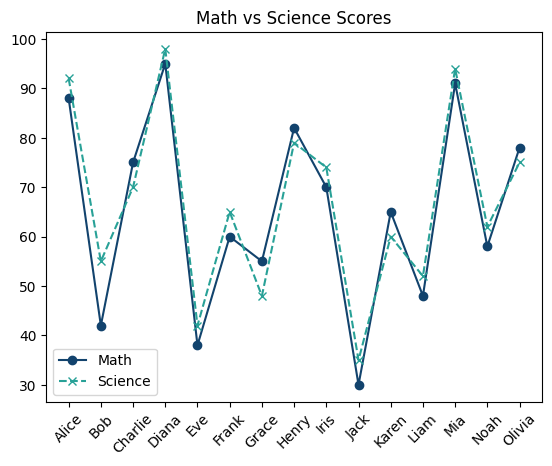

✓Saved: plot5_lineplot.png


In [13]:
# Creating the Line Plot

plt.figure()
plt.plot(df["name"], df["math"], marker='o', linestyle="-", color="#12436D", label="Math")
plt.plot(df["name"], df["science"], marker='x', linestyle="--", color="#28A197", label="Science")

plt.xticks(rotation=45)
plt.legend()
plt.title("Math vs Science Scores")

plt.savefig("plot5_line.png")
plt.show()
print("✓Saved: plot5_lineplot.png")

**Task 3 — Data Visualization with Seaborn**

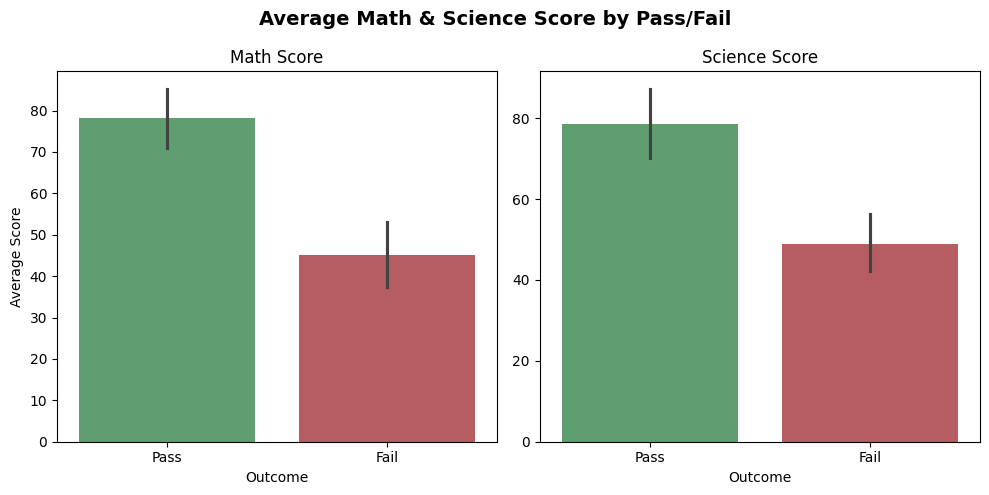

✓Saved: plot6_seaborn_bar.png


In [14]:
# Creating Seaborn Bar Plot

df_plot = df.copy()
df_plot['passed_label'] = df_plot['passed'].map({1: 'Pass', 0: 'Fail'})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Average Math & Science Score by Pass/Fail", fontsize=14, fontweight="bold")

sns.barplot(data=df_plot, x="passed_label", y="math", ax=ax1, palette={'Fail': "#C44E52", 'Pass': "#55A868"}, order=['Pass', 'Fail'], hue="passed_label", legend=False)
ax1.set_title("Math Score")
ax1.set_xlabel("Outcome")
ax1.set_ylabel("Average Score")

sns.barplot(data=df_plot, x="passed_label", y="science", ax=ax2,
            palette={'Fail': "#C44E52", 'Pass': "#55A868"}, order=['Pass', 'Fail'], hue="passed_label", legend=False)
ax2.set_title("Science Score")
ax2.set_xlabel("Outcome")
ax2.set_ylabel("")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png", dpi=150)
plt.show()
plt.close()
print("✓Saved: plot6_seaborn_bar.png")

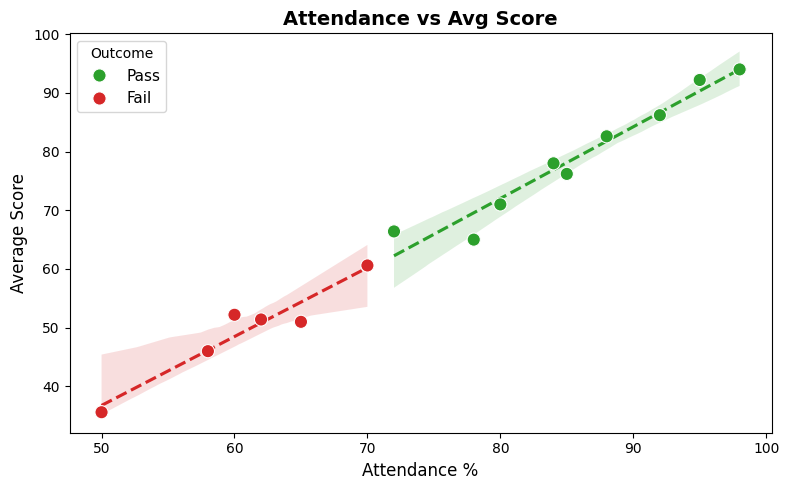

✓Saved: plot7_seaborn_scatter.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_plot, x="attendance_pct", y="avg_score", hue="passed_label", palette={'Fail': '#d62728', 'Pass': '#2ca02c'}, ax=ax, s=90, edgecolors='white', zorder=3)
sns.regplot(data=df_plot[df_plot["passed_label"]=="Fail"], x="attendance_pct", y="avg_score", color='#d62728', ax=ax, scatter=False, line_kws={'linestyle': '--'})
sns.regplot(data=df_plot[df_plot["passed_label"]=="Pass"], x="attendance_pct", y="avg_score", color='#2ca02c', ax=ax, scatter=False, line_kws={'linestyle': '--'})

ax.set_title("Attendance vs Avg Score", fontsize=14, fontweight='bold')
ax.set_xlabel("Attendance %", fontsize=12)
ax.set_ylabel("Average Score", fontsize=12)
ax.legend(title='Outcome', fontsize=11)

plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png", dpi=150)
plt.show()
print("✓Saved: plot7_seaborn_scatter.png")

Seaborn is easier to use for statistical plots and provides better default styling. Matplotlib requires more manual work but gives full control over customization.

**Task 4 — Machine Learning with scikit-learn**

In [16]:
# Step 1 — Prepare Data:

# Prepare data for Machine learning

X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

# Split in train and test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scalling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Step 2 — Train a Model:

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("Training Accuracy:", model.score(X_train_scaled, y_train))

Training Accuracy: 1.0


In [18]:
# Step 3 — Evaluate the Model:

# Testing

y_pred = model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 1.0


In [19]:
# Prediction Result

names = df.loc[X_test.index, "name"]

for i in range(len(names)):
    actual = y_test.iloc[i]
    pred = y_pred[i]
    status = "✅" if actual == pred else "❌"
    print(names.iloc[i], "| Actual:", actual, "| Predicted:", pred, "| Accuracy:", status)

Jack | Actual: 0 | Predicted: 0 | Accuracy: ✅
Liam | Actual: 0 | Predicted: 0 | Accuracy: ✅
Alice | Actual: 1 | Predicted: 1 | Accuracy: ✅


In [20]:
# Step 4 — Feature Importance:

# Model co-efficients in order of importance

coeff = model.coef_[0]
features = X.columns

feat_importance = sorted(zip(features, coeff), key=lambda x: abs(x[1]), reverse=True)

print("Model co-efficients in order of importance:\n")

for f, c in feat_importance:
    print(f"{f}: {c}")

Model co-efficients in order of importance:

english: 0.8125127982724648
attendance_pct: 0.521876340433209
study_hours_per_day: 0.4844326627100155
pe: 0.47497406284967797
math: 0.43794393086873595
science: 0.3230097624690249
history: 0.26292892629062437


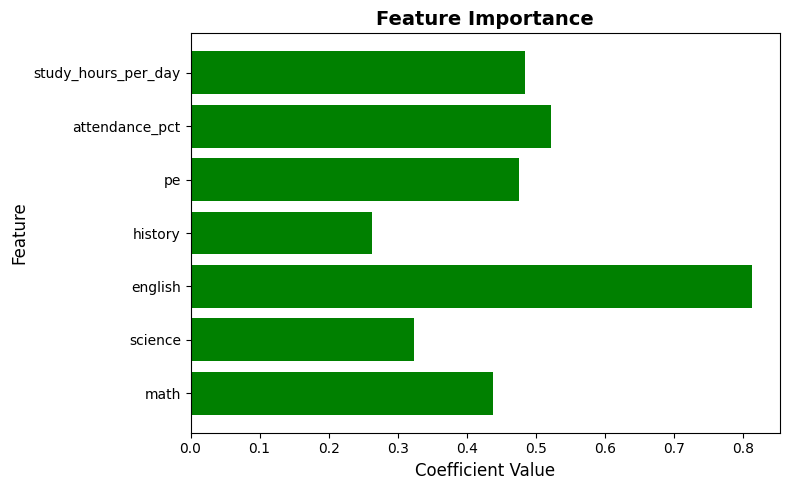

In [21]:
# Feature Importance Plot

colors = ['green' if c > 0 else 'red' for c in coeff]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(features, coeff, color=colors)
ax.set_title("Feature Importance", fontsize=14, fontweight='bold')
ax.set_xlabel("Coefficient Value", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# Step 5 — Predict for a New Student

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)[0]
probabilities = model.predict_proba(new_student_scaled)[0]

outcome = "PASS" if prediction == 1 else "FAIL"
print(f"Prediction     : {outcome}")
print(f"Probability    : Pass={probabilities[1]:.2%}  |  Fail={probabilities[0]:.2%}")

Prediction     : PASS
Probability    : Pass=90.80%  |  Fail=9.20%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
